# kNN osuus - Kim E.

In [11]:
#otetaan tarvittavat kirjastot ja prepataan datasetti. siivota ei tarvitse koska se on jo done.

#tarvittavat libit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#sit datasetti

df_raw = pd.read_csv("cicids2017_cleaned.csv")
df100k = df_raw.sample(n=100000, random_state=42)

#otetaan yhdessä sovitut 10 featuree
df = df100k[[
    'Init_Win_bytes_forward',
    'Flow IAT Mean',
    'Packet Length Std',
    'Subflow Fwd Bytes',
    'Flow Duration',
    'Bwd Packet Length Mean',
    'Total Length of Fwd Packets',
    'PSH Flag Count',
    'Flow Packets/s',
    'Destination Port',
    'Attack Type'
]]

X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

#varmistan tässä et smote toimii
print("classi distribuutio 100k samplessä")
print(y.value_counts())

#jaetaan data % 60 20 20. 60 traini, 20 validaatio, 20 testi.

#eka splitti
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

#toka splitti
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"koko data koko: {len(df)}")
print(f"trainisetin koko:  {len(X_train)}")
print(f"validaatiosetin koko: {len(X_val)}")
print(f"testisetin koko:   {len(X_test)}")


classi distribuutio 100k samplessä
Attack Type
Normal Traffic    83081
DoS                7673
DDoS               5115
Port Scanning      3574
Brute Force         377
Web Attacks          92
Bots                 88
Name: count, dtype: int64
koko data koko: 100000
trainisetin koko:  60000
validaatiosetin koko: 20000
testisetin koko:   20000


In [ ]:
#nonni, nyt ku on tehty splitti ja prepattu kaikki voidaan alkaa tekee pipelien

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', 'passthrough'),     
    ('dim_reduction', 'passthrough'), 
    ('knn', KNeighborsClassifier())
])

#määritellää hyperparametrit - ja että harkka-aika pysyy hanskas tehdää targeted grid searchi...

param_grid = [
    {
        'scaler': [StandardScaler(), MinMaxScaler()],
        'smote': ['passthrough', SMOTE(random_state=42)], #testattii ilman smotea ja sen kanssa.
        'dim_reduction': ['passthrough', PCA(n_components=0.95)],
        'knn__n_neighbors': [3, 5, 7],
        'knn__weights': ['uniform', 'distance'],
        'knn__p': [1, 2] 
    }
]

#sit alotetaa grid search.

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3, 
    scoring='accuracy',
    n_jobs=-1, # seb verran jäte pc mil tätä tein, että käytetää kaikkia saatavil olevia coreja jotten vanhene tän testin kesken. otettiin kanssa vaan 288 mallia mitä käydään läpi.
    verbose=2
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print("parhaan mallin configuraatio")
print(grid_search.best_params_)

Fitting 3 folds for each of 96 candidates, totalling 288 fits
parhaan mallin configuraatio
{'dim_reduction': 'passthrough', 'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance', 'scaler': StandardScaler(), 'smote': 'passthrough'}


harkkadatan tarkkuus:   1.0000
validaatiodatan tarkkuus: 0.9856
testin tarkkuus:    0.9847


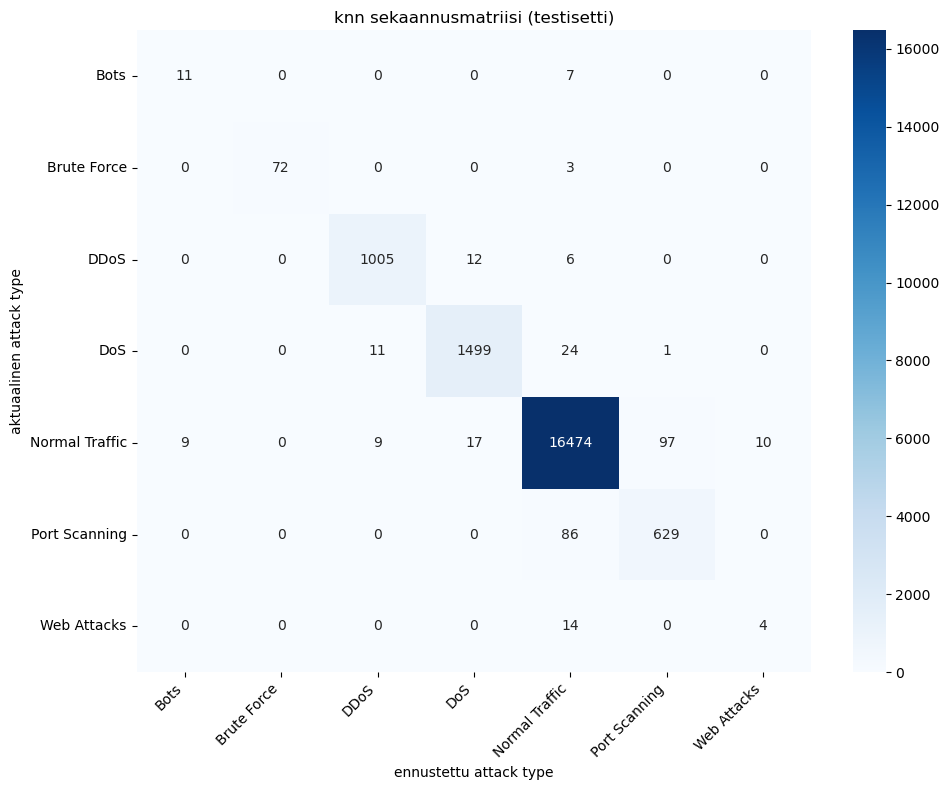

                precision    recall  f1-score   support

          Bots       0.55      0.61      0.58        18
   Brute Force       1.00      0.96      0.98        75
          DDoS       0.98      0.98      0.98      1023
           DoS       0.98      0.98      0.98      1535
Normal Traffic       0.99      0.99      0.99     16616
 Port Scanning       0.87      0.88      0.87       715
   Web Attacks       0.29      0.22      0.25        18

      accuracy                           0.98     20000
     macro avg       0.81      0.80      0.80     20000
  weighted avg       0.98      0.98      0.98     20000



In [ ]:
#evaluaatiot ja tulokset.

#harkkadatan, validation datan ja viimine performance testi datalle.

train_preds = best_model.predict(X_train)
train_acc = accuracy_score(y_train, train_preds)

val_preds = best_model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)

test_preds = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print(f"harkkadatan tarkkuus:   {train_acc:.4f}")
print(f"validaatiodatan tarkkuus: {val_acc:.4f}")
print(f"testin tarkkuus:    {test_acc:.4f}")

#sekaannusmatriisi eli confuosion matrix

cm = confusion_matrix(y_test, test_preds)

#plotataan c-matrix

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('knn sekaannusmatriisi (testisetti)')
plt.ylabel('aktuaalinen attack type')
plt.xlabel('ennustettu attack type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#viimiseks raportti

print(classification_report(y_test, test_preds))

testattu smotella ja ilman smotea, malli valitsi jättää smoten pois koska gridsearch on tehty alunperin yleistä tarkkuutta silmälläpitäen(jäätävä kasa normal trafikkiä). malli menettää kyvyn havaita noita pieniä arvoja bots ja web attacks. sen huomaa kun kattoo että precision on vaan 0.29 ja recall 0.22 esim web attackeissa.

summa summaarum, se mitä tän pitäis tehdä niin onnistuu ihan hyvin näinkin pienellä koulutuksella.